In [71]:
# to_save, to_load = False, True
session_file = "./tmp/TIC_208155474_EW_contaminated_multi.ipynb.pkl"

# # load/save the notebook session
# # https://dill.readthedocs.io/en/latest/
# if True: 
#     import dill
#     import sys
#     if "../" not in sys.path:  # to get my usual helpers at base dir
#         sys.path.append("../")
#     if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
#         sys.path.append("../eb_with_diff_sb_period/etv/")
#     dill.load_module(session_file)
#     %matplotlib inline
#     print(f"Notebook session loaded from  {session_file}")

# if True:  # save the notebook session
#     import dill
#     dill.dump_module(session_file)
#     print(f"Notebook session saved in {session_file}")


Notebook session saved in ./tmp/TIC_208155474_EW_contaminated_multi.ipynb.pkl


In [1]:
import sys
if "../" not in sys.path:  # to get my usual helpers at base dir
    sys.path.append("../")

import lightkurve as lk
from lightkurve_ext import of_sector, of_sectors, of_2min_cadences
import lightkurve_ext as lke
from lightkurve_ext import TransitTimeSpec, TransitTimeSpecList
import lightkurve_ext_tess as lket
import lightkurve_ext_pg as lke_pg
import lightkurve_ext_pg_runner as lke_pg_runner
import tic_plot as tplt

import asyncio_compat

import math
import re
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplotlib

import pandas as pd
import astropy as astropy
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time, TimeDelta
from astropy.io import fits

from matplotlib.ticker import (FormatStrFormatter, AutoMinorLocator)

from importlib import reload # useful during development to reload packages

from IPython.display import display, HTML, Javascript, clear_output

display(HTML("<style>.container { width:99% !important; }</style>"))  # Jupyter 6
display(HTML("<style>.jp-Notebook { --jp-notebook-max-width: 98%; }</style>"))  # Jupyter 7


# No longer works in Jupyter 7+
display(Javascript("""
// export notebook url to Python for bokeh-based interactive features
if (window["IPython"] != null) {
  IPython.notebook.kernel.execute(`notebook_url = "${window.location.origin}"`);
} else {
  console.warn("IPython js object not available (in Jupyter 7). Hardcode notebook_url in the notebook itself instead.")
}
"""));
notebook_url = "localhost:8888"

%matplotlib inline

# data cache config
lk_download_dir = '../data'
if hasattr(lk, "conf"):  # default download dir
    lk.conf.cache_dir = lk_download_dir

# make markdown table aligned to the left of the cell output (instead of center)
display(HTML("<style>table {margin-left: 4ch;}</style>"))

<IPython.core.display.Javascript object>

# TIC 208155474 Analysis (EA)

- Revising existing VSX entry (coordinate inaccurate, blended magnitude)
  - https://vsx.aavso.org/index.php?view=detail.top&oid=711609
- No pre-built lightcurve in TESS data, the closest is TIC 208155466 (6" away, ΔTmag =-0.485), lots of unreliable data there too (e.g., S100, S101 data full of systematics)


## TESS Data

In [2]:
tic = 208155474

sr = lk.search_lightcurve(f"TIC{tic}", )  # author="SPOC", cadence="short"
sr_unfiltered = sr  # keep a copy
sr = lke.filter_by_priority(sr, author_priority = ["QLP"])  # only QLP avaialbel 
# sr = sr[sr.author == "QLP"]  # for uniformity, only 1 sector (3) has no QLP data
# sr = lke._sort_chronologically(sr)

astropy.table.pprint.conf.max_lines = 100  # to print all rows
display(sr)

# Note: only 1 sector of ready made lightcurve
# if needed, lightcurves can be created from sectors 37, 63, 64 (and in the future 90, 99, 100, 101)
lcc_tess = sr.download_all()
lcc_tess

SearchResult containing 0 data products.

C:\pkg\_winNonPortables\miniforge3\envs\my_lk_plus2\Lib\site-packages\lightkurve\search.py:575: LightkurveWarning: Cannot download from an empty search result.
  warnings.warn(


In [ ]:
# _lc = lke.stitch(lcc_tess, corrector_func=lambda lc: lke.select_flux(lc, ["det_flux", "kspsap_flux"]), ignore_incompatible_column_warning=True)  # , corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()

# axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=1, alpha=0.9);
# axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}", fontsize=20);

# axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=1, alpha=0.9);
# axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}, by {_lc.author}, eclipses truncaated", fontsize=20);
# [ax.set_ylim(0.94, 1.03) for ax in axs];

# _lc_f = _lc.fold(period=4.591570, epoch_time=Time(2854.09, format="btjd"), wrap_phase=4.59*0.75)  # # rough initial epoch / period to gauge usefulness of the data
# ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
# ax.set_ylim(0.94, 1.03);

## Gaia DR3 info (coordinate, etc.)

In [3]:
# reload(lke)
# reload (lket)
rs_all_cols, rs, rs_html  = lket.search_gaiadr3_of_tics(tic, radius_arcsec=15, magnitude_range=None,  pm_error_factor=None, pm_range_fraction=None, pm_range_minimum=None, 
                                                        calc_separation_from_first_row=True,  # assuming the first row is the target, it'd calculate more accurately the separation for Gaia DR3 Main
                                                        compact_columns=True, also_return_html=True, also_return_astrophysical=False, verbose_html=True, include_nss_summary_in_html=False)
display(HTML(rs_html))

# from Gaia DR3
target_coord = SkyCoord(rs[0]["RAJ2000"], rs[0]["DEJ2000"], unit=(u.deg, u.deg), frame="icrs")
target_coord_dict = dict(ra=target_coord.ra.value, dec=target_coord.dec.value)


C:\dev\_juypter\PH_TESS_LightCurveViewer\targets\..\lightkurve_ext.py:2316: UserWarning: gaia_dr3_mag_to_vmag(): b_minus_r value (--) is outside the applicable range for the transformation. The result is probably not reliable.
  warnings.warn(


flag,_r,_p,Source,RPmag,Gmag,BPmag,BP-RP,Vmag,Teff,RUWE,sepsi,epsi,NSS,Plx,pmRA,pmDE,VarFlag,RV,e_RV,IPDfmp,Dup,RAJ2000,DEJ2000,EpochPh,EpochRV
,arcsec,deg,,mag,mag,mag,mag,mag,K,,,mas,,mas,mas / yr,mas / yr,,km / s,km / s,,,deg,deg,,
str4,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float32,float64,str48,float64,float64,float64,str34,float64,float32,int16,uint8,float64,float64,uint8,uint8
!! ✓,0.000,0.0,<a target='vizier_gaia_dr3' href='https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-ref=VIZ6578bb1b54eda&-to=-4b&-from=-4&-this=-4&%2F%2Fsource=I%2F355%2Fgaiadr3&%2F%2Ftables=I%2F355%2Fgaiadr3&%2F%2Ftables=I%2F355%2Fparamp&-out.max=50&%2F%2FCDSportal=http%3A%2F%2Fcdsportal.u-strasbg.fr%2FStoreVizierData.html&-out.form=HTML+Table&%2F%2Foutaddvalue=default&-order=I&-oc.form=sexa&-out.src=I%2F355%2Fgaiadr3%2CI%2F355%2Fparamp&-nav=cat%3AI%2F355%26tab%3A%7BI%2F355%2Fgaiadr3%7D%26tab%3A%7BI%2F355%2Fparamp%7D%26key%3Asource%3DI%2F355%2Fgaiadr3%26HTTPPRM%3A&-c=&-c.eq=J2000&-c.r=++2&-c.u=arcmin&-c.geom=r&-source=&-x.rs=10&-source=I%2F355%2Fgaiadr3+I%2F355%2Fparamp&-out.orig=standard&-out=RA_ICRS&-out=DE_ICRS&-out=Source&Source=5831536483793346816&-out=Plx&-out=PM&-out=pmRA&-out=pmDE&-out=sepsi&-out=IPDfmp&-out=RUWE&-out=Dup&-out=Gmag&-out=BPmag&-out=RPmag&-out=BP-RP&-out=RV&-out=e_RV&-out=VarFlag&-out=NSS&-out=XPcont&-out=XPsamp&-out=RVS&-out=EpochPh&-out=EpochRV&-out=MCMCGSP&-out=MCMCMSC&-out=Teff&-out=logg&-out=%5BFe%2FH%5D&-out=Dist&-out=A0&-out=HIP&-out=PS1&-out=SDSS13&-out=SKYM2&-out=TYC2&-out=URAT1&-out=AllWISE&-out=APASS9&-out=GSC23&-out=RAVE5&-out=2MASS&-out=RAVE6&-out=RAJ2000&-out=DEJ2000&-out=Pstar&-out=PWD&-out=Pbin&-out=ABP&-out=ARP&-out=GMAG&-out=Rad&-out=SpType-ELS&-out=Rad-Flame&-out=Lum-Flame&-out=Mass-Flame&-out=Age-Flame&-out=Flags-Flame&-out=Evol&-out=z-Flame&-meta.ucd=0&-meta=0&-usenav=1&-bmark=GET'>5831536483793346816,13.732,14.333,14.734,1.002,14.548,5828.3,3.835,178,0.604,0,1.0949,-4.054,-10.615,"<a target='vizier_gaia_dr3_var' href='https://vizier.cds.unistra.fr/viz-bin/VizieR-4?-ref=VIZ65ac1f481b91d6&-to=-4b&-from=-3&-this=-4&%2F%2Fsource=%2BI%2F358%2Fvarisum%2BI%2F358%2Fvclassre%2BI%2F358%2Fveb%2BI%2F358%2Fvcc%2BI%2F358%2Fvst&%2F%2Fc=06%3A59%3A36.3+%2B23%3A28%3A51.14&%2F%2Ftables=I%2F358%2Fvarisum&%2F%2Ftables=I%2F358%2Fvclassre&%2F%2Ftables=I%2F358%2Fvcc&%2F%2Ftables=I%2F358%2Fveb&%2F%2Ftables=I%2F358%2Fvst&-out.max=50&%2F%2FCDSportal=http%3A%2F%2Fcdsportal.u-strasbg.fr%2FStoreVizierData.html&-out.form=HTML+Table&-out.add=_r&%2F%2Foutaddvalue=default&-sort=_r&-order=I&-oc.form=sexa&-out.src=I%2F358%2Fvarisum%2CI%2F358%2Fvclassre%2CI%2F358%2Fveb%2CI%2F358%2Fvcc%2CI%2F358%2Fvst&-nav=cat%3AI%2F358%26tab%3A%7BI%2F358%2Fvarisum%7D%26tab%3A%7BI%2F358%2Fvclassre%7D%26tab%3A%7BI%2F358%2Fvcc%7D%26tab%3A%7BI%2F358%2Fveb%7D%26tab%3A%7BI%2F358%2Fvst%7D%26key%3Asource%3D%2BI%2F358%2Fvarisum%2BI%2F358%2Fvclassre%2BI%2F358%2Fveb%2BI%2F358%2Fvcc%2BI%2F358%2Fvst%26key%3Ac%3D06%3A59%3A36.3+%2B23%3A28%3A51.14%26pos%3A06%3A59%3A36.3+%2B23%3A28%3A51.14%28+60+arcsec%29%26HTTPPRM%3A&-c=&-c.eq=J2000&-c.r=+60&-c.u=arcsec&-c.geom=r&-source=&-x.rs=10&-source=I%2F358%2Fvarisum+I%2F358%2Fvclassre+I%2F358%2Fveb+I%2F358%2Fvcc+I%2F358%2Fvst&-out.orig=standard&-out=Source&Source=5831536483793346816&-out=RA_ICRS&-out=DE_ICRS&-out=TimeG&-out=DurG&-out=Gmagmean&-out=TimeBP&-out=DurBP&-out=BPmagmean&-out=TimeRP&-out=DurRP&-out=RPmagmean&-out=VCR&-out=VRRLyr&-out=VCep&-out=VPN&-out=VST&-out=VLPV&-out=VEB&-out=VRM&-out=VMSO&-out=VAGN&-out=Vmicro&-out=VCC&-out=SolID&-out=Classifier&-out=Class&-out=ClassSc&-out=Rank&-out=TimeRef&-out=Freq&-out=magModRef&-out=PhaseGauss1&-out=sigPhaseGauss1&-out=DepthGauss1&-out=PhaseGauss2&-out=sigPhaseGauss2&-out=DepthGauss2&-out=AmpCHP&-out=PhaseCHP&-out=ModelType&-out=Nparam&-out=rchi2&-out=PhaseE1&-out=DurE1&-out=DepthE1&-out=PhaseE2&-out=DurE2&-out=DepthE2&-out=Per&-out=T0G&-out=T0BP&-out=T0RP&-out=HG0&-out=HG1&-out=HG2&-out=HG3&-out=HG4&-out=HG5&-out=HBP0&-out=HBP1&-out=HBP2&-out

In [4]:
primary_name = "ASASSN-V J161707.23-594457.9"  # use existing VSX name # f"TIC {tic}"
primary_name

'ASASSN-V J161707.23-594457.9'

## Combining all data



### TESS: remove NEB, systematics / outliers, convert to mag and HJD (N/A)

TODO:

In [ ]:
# helper to review the data interactively
tplt.plot_transit_interactive(_lc, figsize=(30, 8), plot_kwargs=dict(normalize=False, plot_kwargs=dict(s=25),));

In [ ]:
_lc = lke.stitch(lcc_tess, corrector_func=lambda lc: lke.select_flux(lc, ["det_flux", "kspsap_flux"]), ignore_incompatible_column_warning=True,)  # corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()
# _lc_all = _lc  # retain a copy
axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}", fontsize=20);

# remove contamination / outliers, do it in BTJD as it's more familiar to me

_specs = TransitTimeSpecList(
    dict(epoch=Time(2459861.390, format="jd", scale="utc").to_value("btjd"), duration_hr=9, period=55.0384, label="other EB deep", 
        ),
    dict(epoch=Time(2459898.413, format="jd", scale="utc").to_value("btjd"), duration_hr=11.5, period=55.0384, label="other EB shallow", 
        ),
)
duration_factor = 1.2  # mask oout some oot cadence to ensure variation due to transits/eclipses are masked
if _specs is not None:
    tmask = _lc.create_transit_mask(transit_time=_specs.epoch, period=_specs.period, duration=_specs.duration * duration_factor)
    _lc = _lc[~tmask]
    display(HTML("""<b style="background-color: orange;">Note:</b> The contaminant eclipses are masked."""))


for xstart, xstop in [  # scattered light, and systematics
    (1790, 1791.7),
    # (2866.4, 2866.6),  # subsumed by entrie S37  removal
    (2852, 2882.5), # entire S37 detrended flux is scatter
    (2897.5, 2990.5), 
    (3448, 3450), 
    (3590.99, 3591.00),
    (3595.5, 3597.2),
    (3603.90, 3603.91),
    (3605.2, 3606.5),
    (3616, 3617), 
    (3626, 3629),
]:
    _lc = lke.exclude_range(_lc, xstart, xstop)

# QKP sector 18 data has lone outliers associated with momentum dumps, exclude the time around them
for t in np.unique(np.round(lket.MomentumDumpsAccessor.get_in_range(start=1790, end=1816), 2)):
    _lc = lke.exclude_range(_lc, t - 0.05, t + 0.05)


# now we plot

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, eclipses, outliers removed", fontsize=20);

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, y-zoom 0.94 - 1.03", fontsize=20);
[ax.set_ylim(0.94, 1.03) for ax in axs];

_lc_f = _lc.fold(period=4.591570, epoch_time=Time(2854.09, format="btjd"), wrap_phase=4.59*0.75)  # # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
ax.axvline(0, c="lightgray", ls="--");
ax.axvline(4.591570 * 0.5, c="lightgray", ls="--");
time_bin_size = 10 * u.min 
if time_bin_size is not None:
    _lc_f_b = lke.bin_flux(_lc_f, time_bin_size=time_bin_size)  
    tplt.scatter(_lc_f_b, ax=ax, label=f"binned {time_bin_size}", s=9);
    print("bin compression:", len(_lc_f), len(_lc_f_b), round(len(_lc_f) / len(_lc_f_b), 1));

# convert to mag and HJD
lc_tess = _lc
lc_tess = lke.to_flux_in_mag_by_normalization(lc_tess)
lc_tess = lke.convert_lc_time_to_hjd_utc(lc_tess, target_coord=target_coord, cache_dir=lk_download_dir)

#### TESS with small detrended QLP aperture

- Given there is a bright star ~36" away, try out QLP small aperture (`_SML` flux) to see if it changes eclipse depth
- result: no preceptible difference.

In [ ]:
_lc = lke.stitch(lcc_tess, corrector_func=lambda lc: lke.select_flux(lc, ["det_flux_sml", "kspsap_flux_sml"]), ignore_incompatible_column_warning=True,)  # corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()
# _lc_all = _lc  # retain a copy
axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}", fontsize=20);

# remove contamination / outliers, do it in BTJD as it's more familiar to me

_specs = TransitTimeSpecList(
    dict(epoch=Time(2459861.390, format="jd", scale="utc").to_value("btjd"), duration_hr=9, period=55.0384, label="other EB deep", 
        ),
    dict(epoch=Time(2459898.413, format="jd", scale="utc").to_value("btjd"), duration_hr=11.5, period=55.0384, label="other EB shallow", 
        ),
)
duration_factor = 1.2  # mask oout some oot cadence to ensure variation due to transits/eclipses are masked
if _specs is not None:
    tmask = _lc.create_transit_mask(transit_time=_specs.epoch, period=_specs.period, duration=_specs.duration * duration_factor)
    _lc = _lc[~tmask]
    display(HTML("""<b style="background-color: orange;">Note:</b> The contaminant eclipses are masked."""))


for xstart, xstop in [  # scattered light, and systematics
    (1790, 1791.7),
    # (2866.4, 2866.6),  # subsumed by entrie S37  removal
    (2852, 2882.5), # entire S37 detrended flux is scatter
    (2897.5, 2990.5), 
    (3448, 3450), 
    (3590.99, 3591.00),
    (3595.5, 3597.2),
    (3603.90, 3603.91),
    (3605.2, 3606.5),
    (3616, 3617), 
    (3626, 3629),
]:
    _lc = lke.exclude_range(_lc, xstart, xstop)

# QKP sector 18 data has lone outliers associated with momentum dumps, exclude the time around them
for t in np.unique(np.round(lket.MomentumDumpsAccessor.get_in_range(start=1790, end=1816), 2)):
    _lc = lke.exclude_range(_lc, t - 0.05, t + 0.05)


# now we plot

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, eclipses, outliers removed", fontsize=20);

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, y-zoom 0.94 - 1.03", fontsize=20);
[ax.set_ylim(0.94, 1.03) for ax in axs];

_lc_f = _lc.fold(period=4.591570, epoch_time=Time(2854.09, format="btjd"), wrap_phase=4.59*0.75)  # # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
ax.axvline(0, c="lightgray", ls="--");
ax.axvline(4.591570 * 0.5, c="lightgray", ls="--");
time_bin_size = 10 * u.min 
if time_bin_size is not None:
    _lc_f_b = lke.bin_flux(_lc_f, time_bin_size=time_bin_size)  
    tplt.scatter(_lc_f_b, ax=ax, label=f"binned {time_bin_size}", s=9);
    print("bin compression:", len(_lc_f), len(_lc_f_b), round(len(_lc_f) / len(_lc_f_b), 1));
ax.set_title(f"{_lc.label}, detrended QLP small aperture");

# # convert to mag and HJD
# lc_tess_sml = _lc
# lc_tess_sml = lke.to_flux_in_mag_by_normalization(lc_tess_sml)
# lc_tess_sml = lke.convert_lc_time_to_hjd_utc(lc_tess_sml, target_coord=target_coord, cache_dir=lk_download_dir, cache_key_suffix="_sml")

#### TESS with QLP SAP_FLUX

- huge systematics

In [ ]:
_lc = lke.stitch(lcc_tess, corrector_func=lambda lc: lke.select_flux(lc, "sap_flux"), ignore_incompatible_column_warning=True,)  # corrector_func=lambda lc: lc.select_flux("sap_flux").normalize()
# _lc_all = _lc  # retain a copy
axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, sectors {lke.abbrev_sector_list(_lc)}", fontsize=20);

# remove contamination / outliers, do it in BTJD as it's more familiar to me

_specs = TransitTimeSpecList(
    dict(epoch=Time(2459861.390, format="jd", scale="utc").to_value("btjd"), duration_hr=9, period=55.0384, label="other EB deep", 
        ),
    dict(epoch=Time(2459898.413, format="jd", scale="utc").to_value("btjd"), duration_hr=11.5, period=55.0384, label="other EB shallow", 
        ),
)
duration_factor = 1.2  # mask oout some oot cadence to ensure variation due to transits/eclipses are masked
if _specs is not None:
    tmask = _lc.create_transit_mask(transit_time=_specs.epoch, period=_specs.period, duration=_specs.duration * duration_factor)
    _lc = _lc[~tmask]
    display(HTML("""<b style="background-color: orange;">Note:</b> The contaminant eclipses are masked."""))


for xstart, xstop in [  # scattered light, and systematics
    (1790, 1791.7),
    # (2866.4, 2866.6),  # subsumed by entrie S37  removal
    (2852, 2882.5), # entire S37 detrended flux is scatter
    (2897.5, 2990.5), 
    (3448, 3450), 
    (3590.99, 3591.00),
    (3595.5, 3597.2),
    (3603.90, 3603.91),
    (3605.2, 3606.5),
    (3616, 3617), 
    (3626, 3629),
]:
    _lc = lke.exclude_range(_lc, xstart, xstop)

# QKP sector 18 data has lone outliers associated with momentum dumps, exclude the time around them
for t in np.unique(np.round(lket.MomentumDumpsAccessor.get_in_range(start=1790, end=1816), 2)):
    _lc = lke.exclude_range(_lc, t - 0.05, t + 0.05)


# now we plot

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, eclipses, outliers removed", fontsize=20);

axs = tplt.plot_skip_data_gap(_lc, figsize=(30,5), s=9, alpha=0.9);
axs[0].get_figure().suptitle(f"{_lc.label}, y-zoom 0.94 - 1.03", fontsize=20);
[ax.set_ylim(0.94, 1.03) for ax in axs];

_lc_f = _lc.fold(period=4.591570, epoch_time=Time(2854.09, format="btjd"), wrap_phase=4.59*0.75)  # # rough initial epoch / period to gauge usefulness of the data
ax = tplt.scatter(_lc_f, c=_lc_f.time_original.value);
ax.axvline(0, c="lightgray", ls="--");
ax.axvline(4.591570 * 0.5, c="lightgray", ls="--");
time_bin_size = 10 * u.min 
if time_bin_size is not None:
    _lc_f_b = lke.bin_flux(_lc_f, time_bin_size=time_bin_size)  
    tplt.scatter(_lc_f_b, ax=ax, label=f"binned {time_bin_size}", s=9);
    print("bin compression:", len(_lc_f), len(_lc_f_b), round(len(_lc_f) / len(_lc_f_b), 1));
ax.set_title(f"{_lc.label}, detrended QLP small aperture");

# # convert to mag and HJD
# lc_tess_sap = _lc
# lc_tess_sap = lke.to_flux_in_mag_by_normalization(lc_tess_sap)
# lc_tess_sap = lke.convert_lc_time_to_hjd_utc(lc_tess_sap, target_coord=target_coord, cache_dir=lk_download_dir, cache_key_suffix="_sap")

#### TESS flux to use: conclusion

- sticks with the default detrended flux `kspsap_flux` / `det_flux`

### Gaia DR3 data

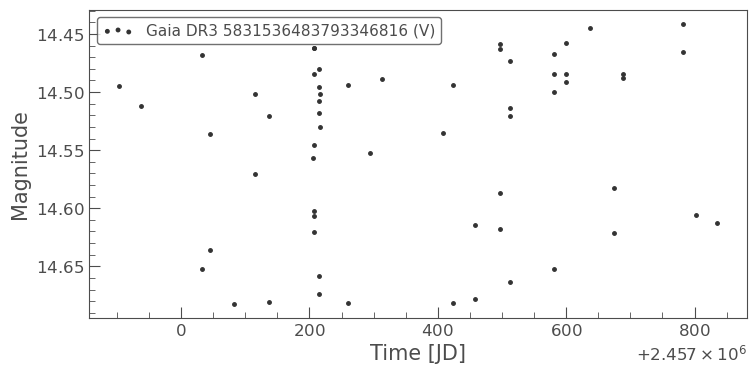

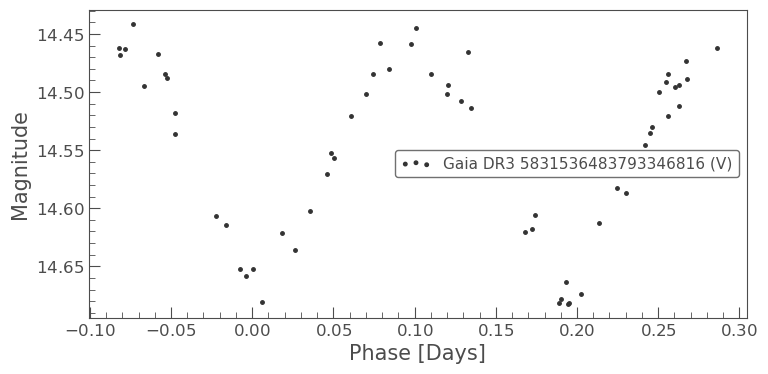

In [5]:
from io import StringIO
from astropy.table import Table

# plot: https://cdsarc.cds.unistra.fr//vizier/vizgraph.gml?-s=I/355&-i=.graph_sql_epphot&Pos=244.27894496194-59.75065147156&Source=5831536483793346816
# data: https://cdsarc.cds.unistra.fr/viz-bin/vizgraph?--output=png+&-s=I%2F355&-i=.graph_sql_epphot&Pos=244.27894496194-59.75065147156&Source=5831536483793346816&--output=tsv
# only the Gmag portion
# VizieR  - Graph output I/355 light curves of Gaia DR3 5831536483793346816
# Resource:G
# JD-2455197.5
# G [mag]
_tab = Table.read(
    """\
time 	 mag	
1705.700339 	14.280210	
1740.826066 	14.296978	
1835.693989 	14.253383	
1835.768027 	14.437698	
1847.199002 	14.320729	
1847.272993 	14.420949	
1884.913830 	14.467039	
1917.650304 	14.355486	
1917.724301 	14.287045	
1939.405665 	14.465725	
1939.655822 	14.305308	
2008.659945 	14.341535	
2008.910105 	14.247459	
2009.160234 	14.405508	
2009.234267 	14.330476	
2009.410418 	14.387657	
2009.484422 	14.269051	
2009.660571 	14.246674	
2009.734574 	14.391479	
2017.488911 	14.264752	
2017.665086 	14.280250	
2017.739089 	14.303352	
2017.915239 	14.292944	
2017.989242 	14.459037	
2018.165393 	14.443588	
2018.239398 	14.286955	
2018.415550 	14.315388	
2062.645802 	14.278696	
2062.719803 	14.466120	
2097.369528 	14.337403	
2115.943200 	14.273702	
2209.985159 	14.320295	
2225.988531 	14.466324	
2226.062515 	14.278785	
2260.786190 	14.462969	
2260.962362 	14.399680	
2299.446514 	14.371890	
2299.520533 	14.247570	
2299.696701 	14.243682	
2299.770712 	14.403062	
2314.704494 	14.448507	
2314.778475 	14.258034	
2314.954700 	14.305223	
2315.028679 	14.298429	
2382.957143 	14.437251	
2383.031147 	14.269185	
2383.207298 	14.285111	
2383.281329 	14.252031	
2402.536640 	14.242375	
2402.712785 	14.276092	
2402.786816 	14.269217	
2439.267159 	14.230036	
2476.481529 	14.367292	
2476.657669 	14.406572	
2490.660629 	14.269663	
2490.734632 	14.272542	
2584.602408 	14.250292	
2584.778577 	14.226090	
2604.909839 	14.390968	
2637.068651 	14.398048""".splitlines()
,
    format="ascii.csv",
    delimiter="\t",
)

_lc = lk.LightCurve(time=Time(_tab["time"] + 2455197.5, format="jd", scale="tdb"), flux=_tab["mag"] * u.mag)

_lc["flux_err"] = 0.004314 * u.mag  # use mean Gmag error for now -- https://vizier.cds.unistra.fr/viz-bin/VizieR-5?-ref=VIZ6a32e5ae3175d&-out.add=.&-source=I/355/gaiadr3&-c=244.27894496194%20-59.75065147156,eq=ICRS,rs=2&-out.orig=o

_lc["gmag"] = _lc["flux"]
_lc["gmag_err"] = _lc["flux_err"]

# Gaia DR3 G to V transform
# SO: the G-to-V transform can be done via a linear offset of the G to V based on the mean G mag and mean B-R
# given the target is an EW without color changes throughout the cycle
gdr3_g_to_v_offset = np.round(14.548 - 14.333, 3) * u.mag
_lc["flux"] += gdr3_g_to_v_offset


_lc.meta["TARGET"] = "Gaia DR3 5831536483793346816 (V)"
_lc.meta["LABEL"] = "Gaia DR3 5831536483793346816 (V)"
tplt.scatter(_lc, s=25);


# TODO: transform to V

lc_gdr3 = _lc 

lc_gdr3 = lke.convert_lc_time_to_hjd_utc(lc_gdr3, target_coord=target_coord, cache_dir=lk_download_dir, cache_key="gdr3_5831536483793346816")

# rough folded LC to visualiz the results
_lc_f = lc_gdr3.fold(epoch_time=Time(2458306.59, format="jd", scale="utc"), period=0.382377, wrap_phase=0.382377 * 0.75)
tplt.scatter(_lc_f, s=25);


### ASAS-SN data
- contaminated, deblending done
- rough outliers removal with sigma clip

Gaia DR3 V median: 14.5192875 mag ; mean:  14.545996516666667 mag ; mean from catalog: 14.548
Before deblend, median: 13.796 mag
deblend trial 1, median: 14.508 mag
deblend trial 2, median: 14.519 mag
Gaia DR3 G median: 14.304287500000001 mag ; mean:  14.330996516666668 mag ; mean from catalog: 14.333
Before deblend, median: 14.278 mag
deblend trial g, median: 15.001 mag


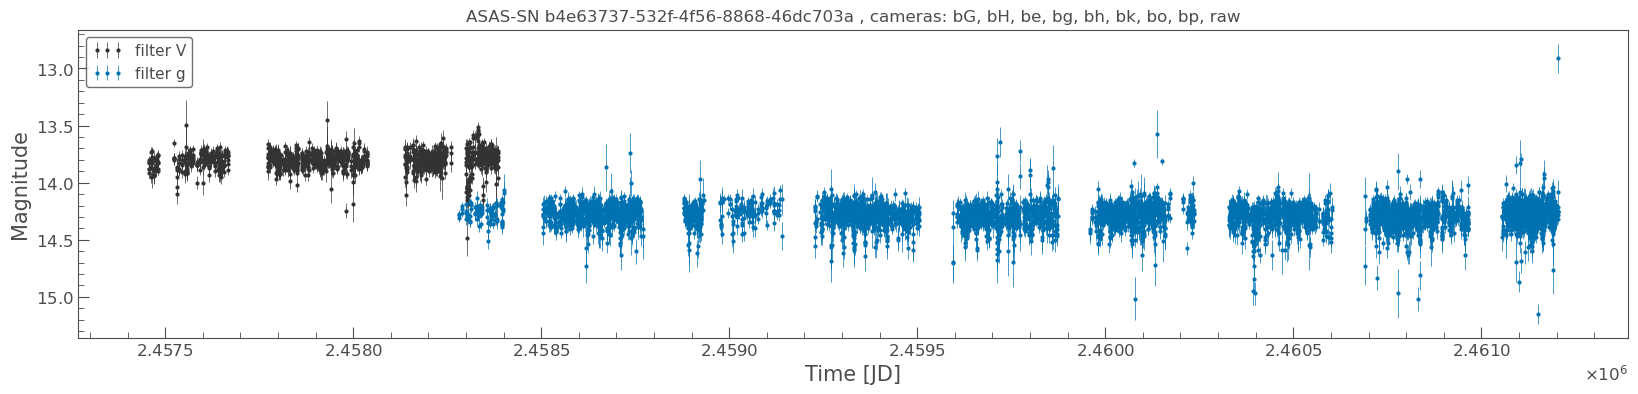

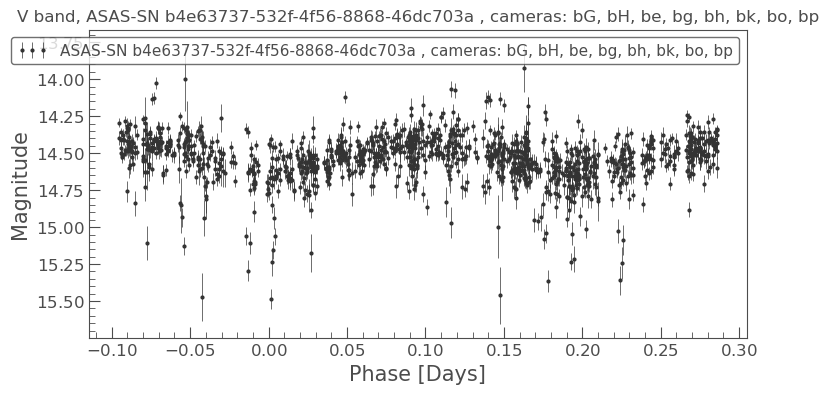

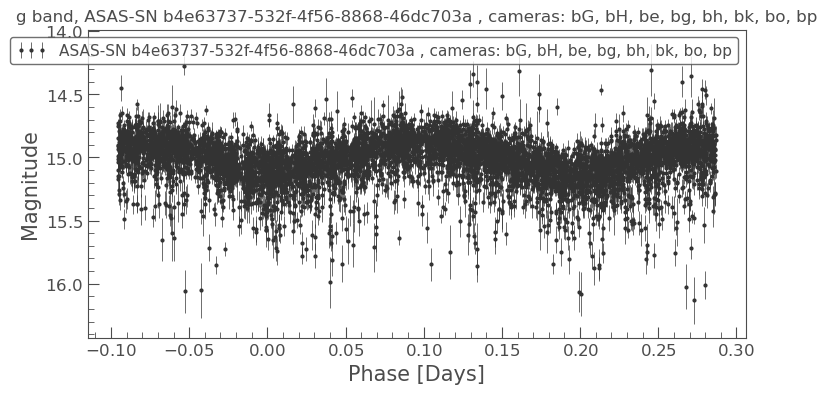

In [7]:
import lightkurve_ext_readers as lker
# reload(lker)
# reload(tplt)

# https://asas-sn.osu.edu/sky-patrol/coordinate/tplt.scatter(_lc[_lc.filter == "V"], partition_by_column="filter", );

_lc = lker.read_asas_sn_csv(f"{lk_download_dir}/targets/tic208155474_asas_sn_light_curve_b4e63737-532f-4f56-8868-46dc703a8ace.csv")  
_lc = _lc.select_flux("mag")
_lc = _lc.remove_nans()
_lc = _lc.remove_nans(column="flux_err")

ax = tplt.lk_ax(figsize=(20, 4))
ax = tplt.errorbar_partition_by(_lc, partition_by_column="filter", ax=ax);
ax.set_title(ax.get_title() + ", raw");

# de-blending the contaminated ASAS-SN mag

print("Gaia DR3 V median:", np.nanmedian(lc_gdr3.flux), "; mean: ", np.nanmean(lc_gdr3.flux),  "; mean from catalog:", 14.548);

_lc_v = _lc[_lc.filter == "V"].remove_outliers(sigma=5)
print("Before deblend, median:", np.round(np.nanmedian(_lc_v.flux), 3));

_lc_v_db = lke.deblend_mag(_lc_v, 14.591)  # Vmag the brightest contaminant ~6" away, Gaia DR3 	5831536483793347712	
print("deblend trial 1, median:", np.round(np.nanmedian(_lc_v_db.flux), 3));

_lc_v_db = lke.deblend_mag(_lc_v, 14.579)  # manual adjustment the combined contaminatn mag so that th median matches Gaia DR3 V
print("deblend trial 2, median:", np.round(np.nanmedian(_lc_v_db.flux), 3));


lc_asassn_v = _lc_v_db
lc_asassn_v["flux_err"] = _lc_v.flux_err  # Needed the error for the MCMC step below. the codes can't deblend the error yet, for now just take the blended value. 

# ---

print("Gaia DR3 G median:", np.nanmedian(lc_gdr3.gmag), "; mean: ", np.nanmean(lc_gdr3.gmag),  "; mean from catalog:", 14.333);
_lc_g = _lc[_lc.filter == "g"].remove_outliers(sigma=5)
print("Before deblend, median:", np.round(np.nanmedian(_lc_g.flux), 3));

# for g band, gapproximate the beblendign by assuming the smae portion of contamianted flux as the one in V band
_lc_g_db = lke.deblend_mag(_lc_g, ((14.579 -13.796) * u.mag + np.round(np.nanmedian(_lc_g.flux), 3)).value)
print("deblend trial g, median:", np.round(np.nanmedian(_lc_g_db.flux), 3));
lc_asassn_g = _lc_g_db
lc_asassn_g["flux_err"] = _lc_g.flux_err  # Needed the error for the MCMC step below. the codes can't deblend the error yet, for now just take the blended value


# rough folded LC to visualize the results
_lc_f = lc_asassn_v.fold(epoch_time=Time(2458306.59, format="jd", scale="utc"), period=0.382377, wrap_phase=0.382377 * 0.75)
ax = tplt.errorbar(_lc_f);
ax.set_title(f"V band, {_lc.label}");

_lc_f = lc_asassn_g.fold(epoch_time=Time(2458306.59, format="jd", scale="utc"), period=0.382377, wrap_phase=0.382377 * 0.75)
ax = tplt.errorbar(_lc_f);
ax.set_title(f"g band, {_lc.label}");


### Do Actual combining

Gaia DR3 V # data points: 60
ASAS-SN V # data points: 1287
ASAS-SN g # data points: 6918


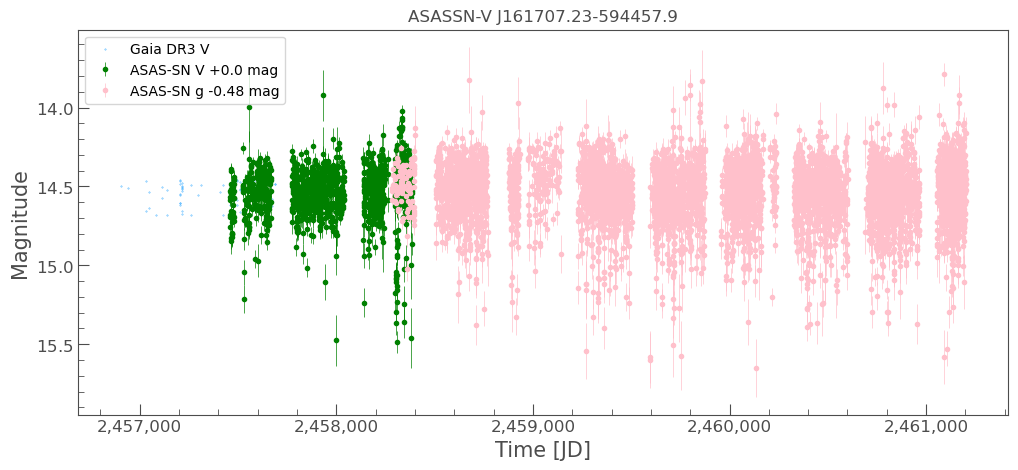

In [8]:
# Convert the data to magnitude and HJD/UTC

import lightkurve_ext_multi_sources as lkem
# reload(lkem)

lc_combined_dict = lkem.combine_multi_bands_and_shift(
    {"Gaia DR3 V": lc_gdr3, 
     "ASAS-SN V": lc_asassn_v,
     "ASAS-SN g": lc_asassn_g,
    }, 
    shift_to="Gaia DR3 V",
)

for k in lc_combined_dict.keys():
    print(f"{k} # data points:", len(lc_combined_dict[k]))

plot_options = lkem.get_default_plot_multi_bands_options_copy()
# for TESS plot (index 0) move it to the front
# plot_options[0][1]["zorder"] = 3  # default 2

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(12, 5), target_name=primary_name, plot_options=plot_options);
# ax.set_ylim(15.2, 14.0);

## Initial epoch / period / duration


Adopted period / epoch / duration_hr:  0.382377 2458306.59 4.5 4.5


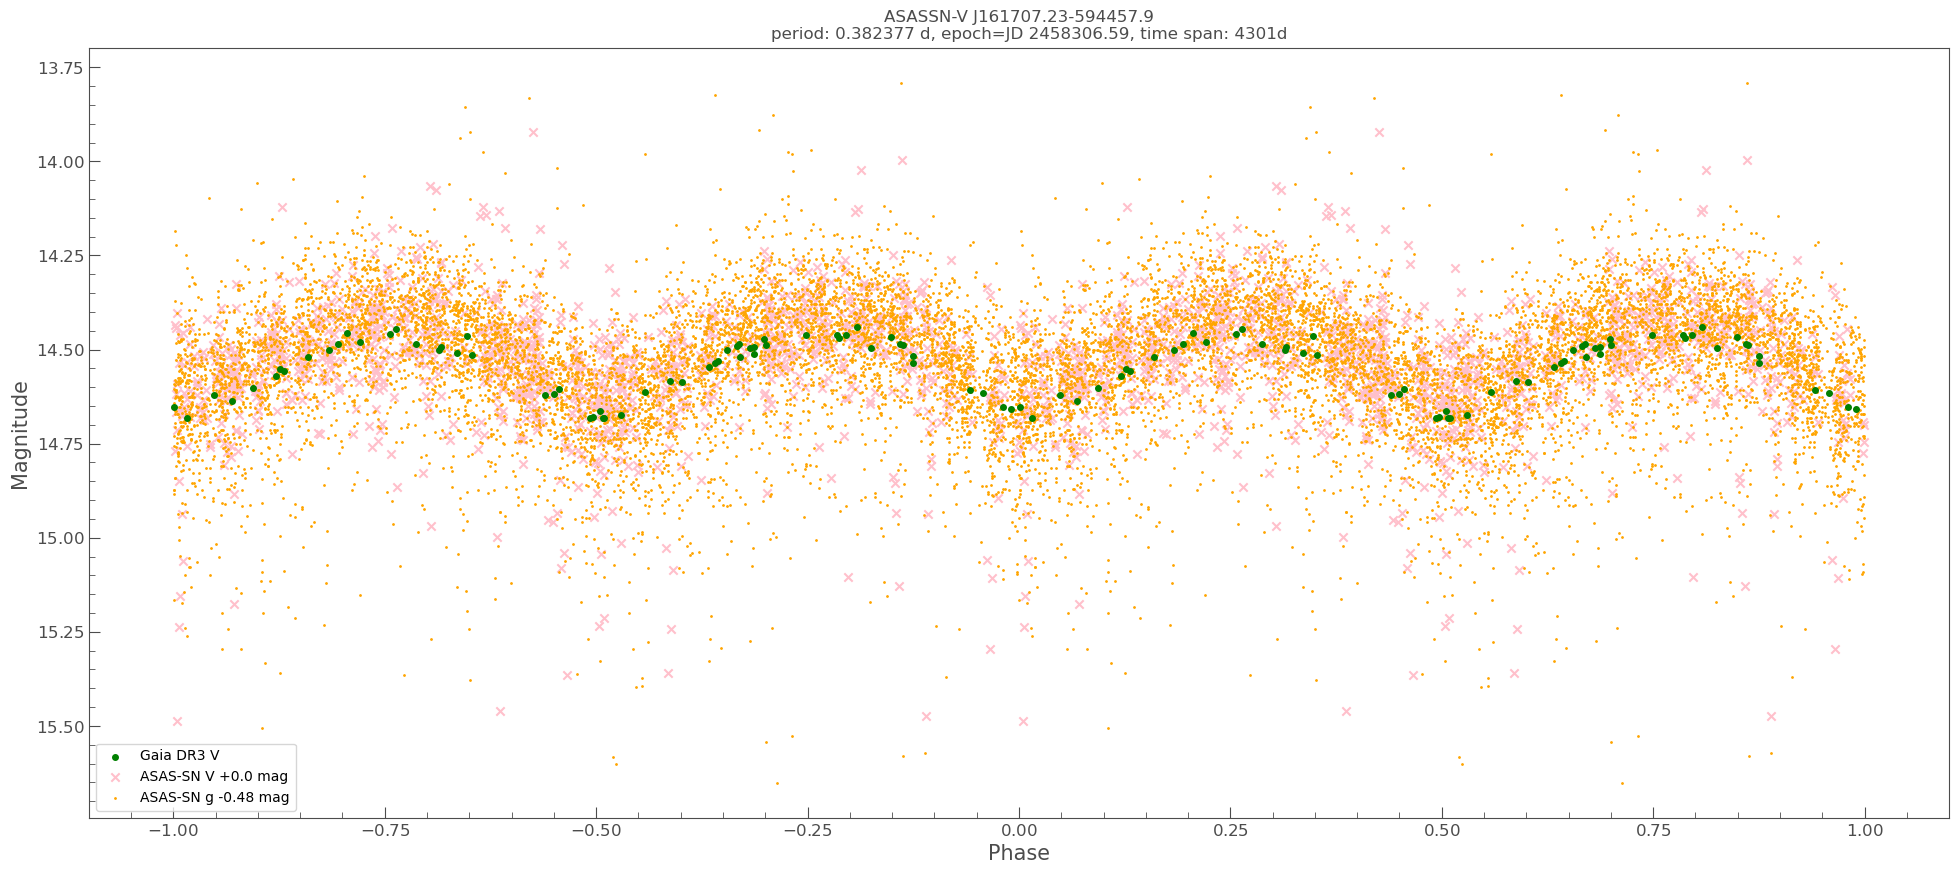

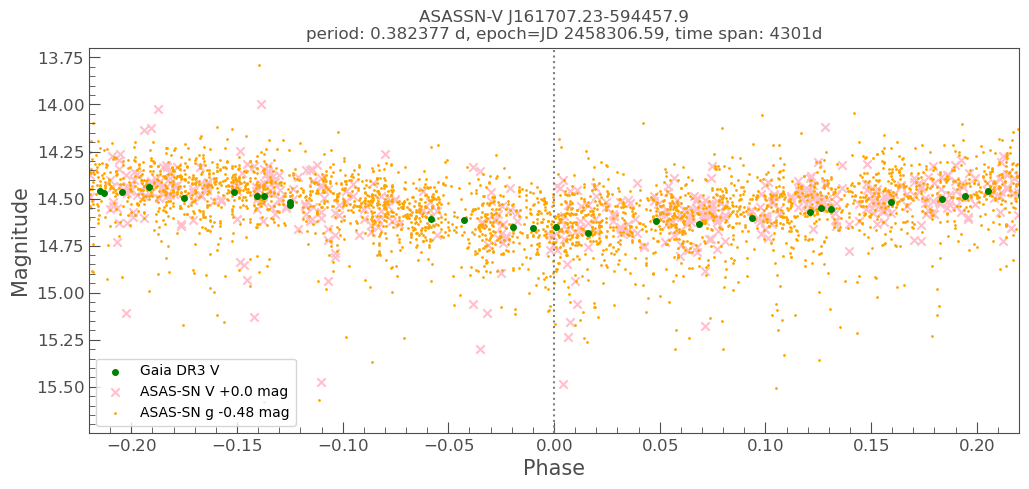

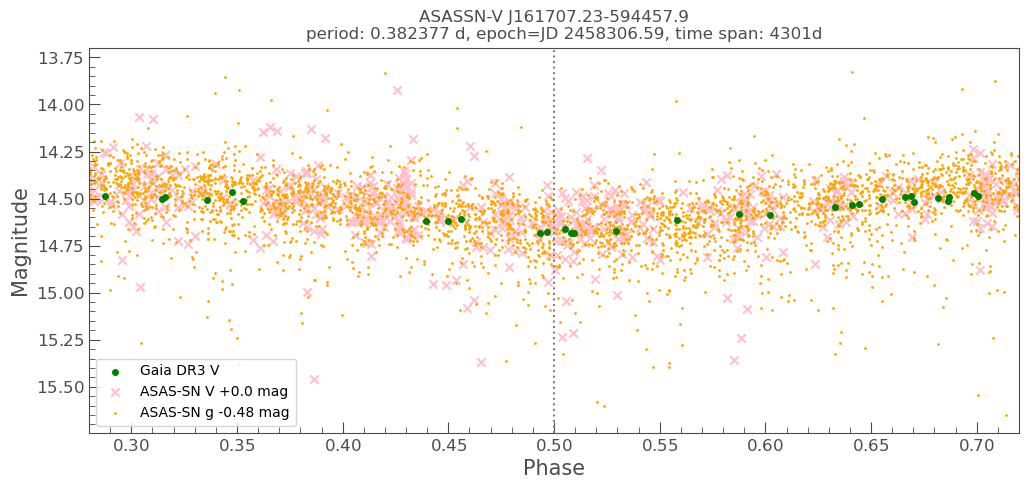

In [9]:
# reload(lkem)

# epoch / period : existing VSX values
period_trial = 0.382377
epoch_time_btjd_trial = 2854.09
epoch_time_hjd_trial = 2458306.59
epoch_time_min_ii_hjd_trial = round(epoch_time_hjd_trial + period_trial * 0.5, 2)  # at phase 0.5
epoch_phase_min_ii_trial   = round(abs(epoch_time_min_ii_hjd_trial   - float(epoch_time_hjd_trial)  ) / period_trial   % 1, 1)

duration_hr_min_i_trial = 4.5  # not real eclipse duration, but just a way to mark the eclipses approximately
duration_hr_min_ii_trial = 4.5



print("Adopted period / epoch / duration_hr: ", period_trial, epoch_time_hjd_trial, duration_hr_min_i_trial, duration_hr_min_ii_trial)

# --- Plot them to verify ---

plot_options = [
    ('scatter', {'c': 'green', 'marker': '.', 's': 64, 'alpha': 1.0, 'zorder': 9}),
    ('scatter', {'c': 'pink', 'marker': 'x', 's': 36, 'alpha': 1.0}),
    ('scatter', {'c': 'orange', 'marker': '.', 's': 4, 'alpha': 1.0}),
]

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - larger dots to be more visible, move TESS to front
plot_options_zoom = plot_options


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_trial  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.22, 0.22);  # to see primary in details
ylim = (None, None)
ax.set_ylim(*ylim);


# zoom plot Min II
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_trial,
    epoch=Time(epoch_time_hjd_trial, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_ii_trial  ,  # for plotting only
    duration_midpoint_phase=epoch_phase_min_ii_trial,
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(epoch_phase_min_ii_trial, c="gray", linestyle="dotted");
ax.set_xlim(epoch_phase_min_ii_trial - 0.22, epoch_phase_min_ii_trial + 0.22);  # to secondary in details
ax.set_ylim(*ylim);


## Period refinement with MCMC


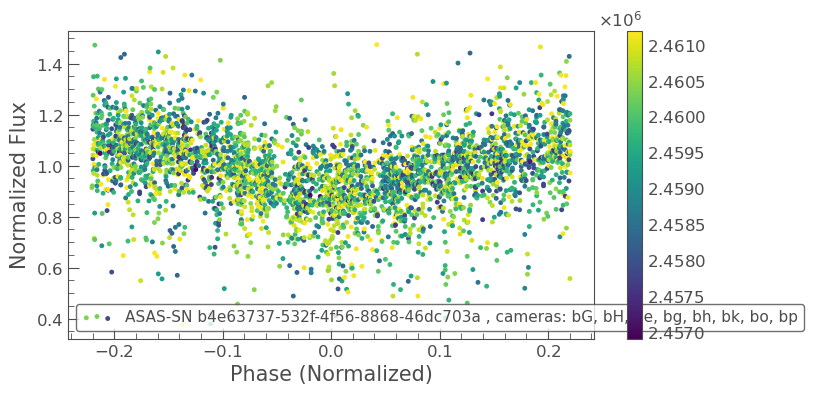

In [10]:
_lc = lke.stitch_lc_dict(lc_combined_dict, normalize=True).remove_nans() 

lc_f_min_i = _lc.fold(epoch_time=epoch_time_hjd_trial, period=period_trial, normalize_phase=True)
lc_f_min_i = lc_f_min_i.truncate((0 - duration_hr_min_i_trial / 24 * 0.45) / period_trial, (0 + duration_hr_min_i_trial /24 * 0.45) / period_trial)
lc_f_min_i = lc_f_min_i.truncate(None, 1.5, column="flux")  # crude outlier removal
ax1 = tplt.scatter(lc_f_min_i, c=lc_f_min_i.time_original.value, s=25);
# ax1 = tplt.errorbar(lc_f_min_i);

In [13]:
from types import SimpleNamespace

import sys
if "../eb_with_diff_sb_period/etv/" not in sys.path:  # for etvp
    sys.path.append("../eb_with_diff_sb_period/etv/")

import etv_functions_with_period as etvp
import etv_functions
# reload(etvp)

lc_f = lc_f_min_i

# # median flux, -eclipse depth, t0, related to duration, related to shape (U or V) 
# # t0 in normalixed phase
start_vals = [1.2, -0.3, 0, 0.14, 1.1]


# convert lc to the form needed by fit etv_functions
lc_f_data = SimpleNamespace(time=lc_f.time_original.value, phase=lc_f.time.value, flux=np.array(lc_f.flux.value), err=np.array(lc_f.flux_err.value))
etv_functions.plot_initial_guess_interactive(lc_f_data, None, None, None, "0", *start_vals)

Output(layout=Layout(padding='1em 0px'), outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Fig…

Output(layout=Layout(padding='1em'), outputs=({'name': 'stdout', 'text': '[1.2, -0.3, 0, 0.14, 1.1]\n\n', 'out…

100%|██████████████████████████████████████████████████████████| 4000/4000 [06:35<00:00, 10.12it/s]


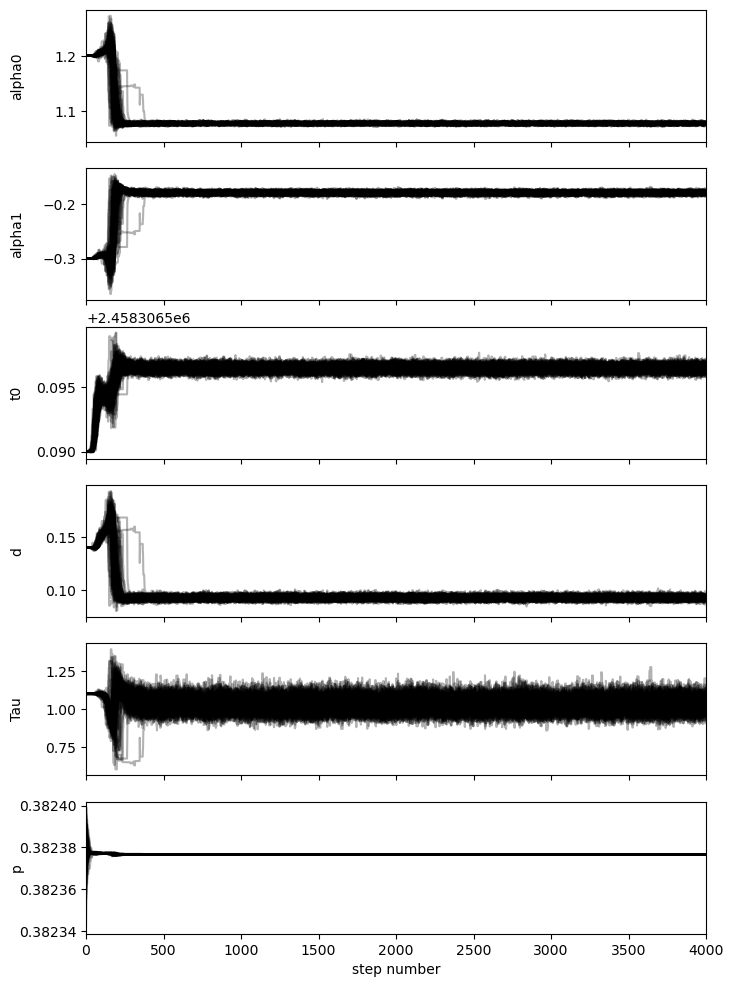

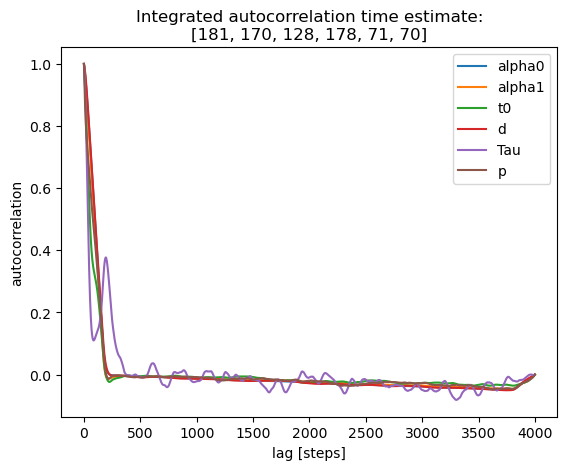

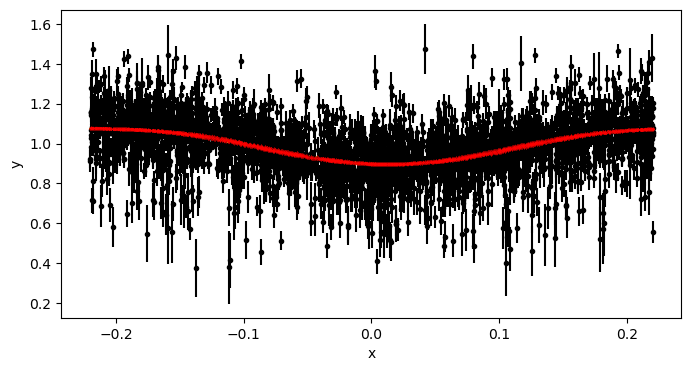

mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = 1.0775701906850546, -0.1796815380694386, 2458306.596478733, 0.092446239059671, 1.0287371429058951, 0.38237662036731473
std_t0: 0.0002471349821651831
std_p: 6.141545212352755e-08


In [16]:
mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p, fit_params_p_stats  = etvp.run_mcmc_initial_fit_p(
    lc_f_data, 
    [1.2, -0.3, epoch_time_hjd_trial, 0.14, 1.1, period_trial],
    # nruns=20, discard=1,
    nruns=4000, discard=1000,
    autocorr_time_kwargs=dict(tol=20),  # the emcee defaults tol=50 seems to be too strict for our use case, tol of ~10 - 20 seems to be sufficient    
    pool=-2, 
    plot_chains=True, plot_autocorrelation=True, plot=True, 
    also_return_stats=True,
)

print("mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p = " + ", ".join([str(v) for v in [mean_alpha0, mean_alpha1, mean_t0_time, mean_d, mean_Tau, mean_p]]))
print("std_t0:", fit_params_p_stats["std_t0"])
print("std_p:", fit_params_p_stats["std_p"])


In [17]:
# compare MCMC results above with initial trial
print(epoch_time_hjd_trial,"\n", period_trial)


2458306.59 
 0.382377


## Final period / epoch / duration

Adopted period / epoch / duration_hr:  0.3823766 2458306.60 0.5 4.5 4.5


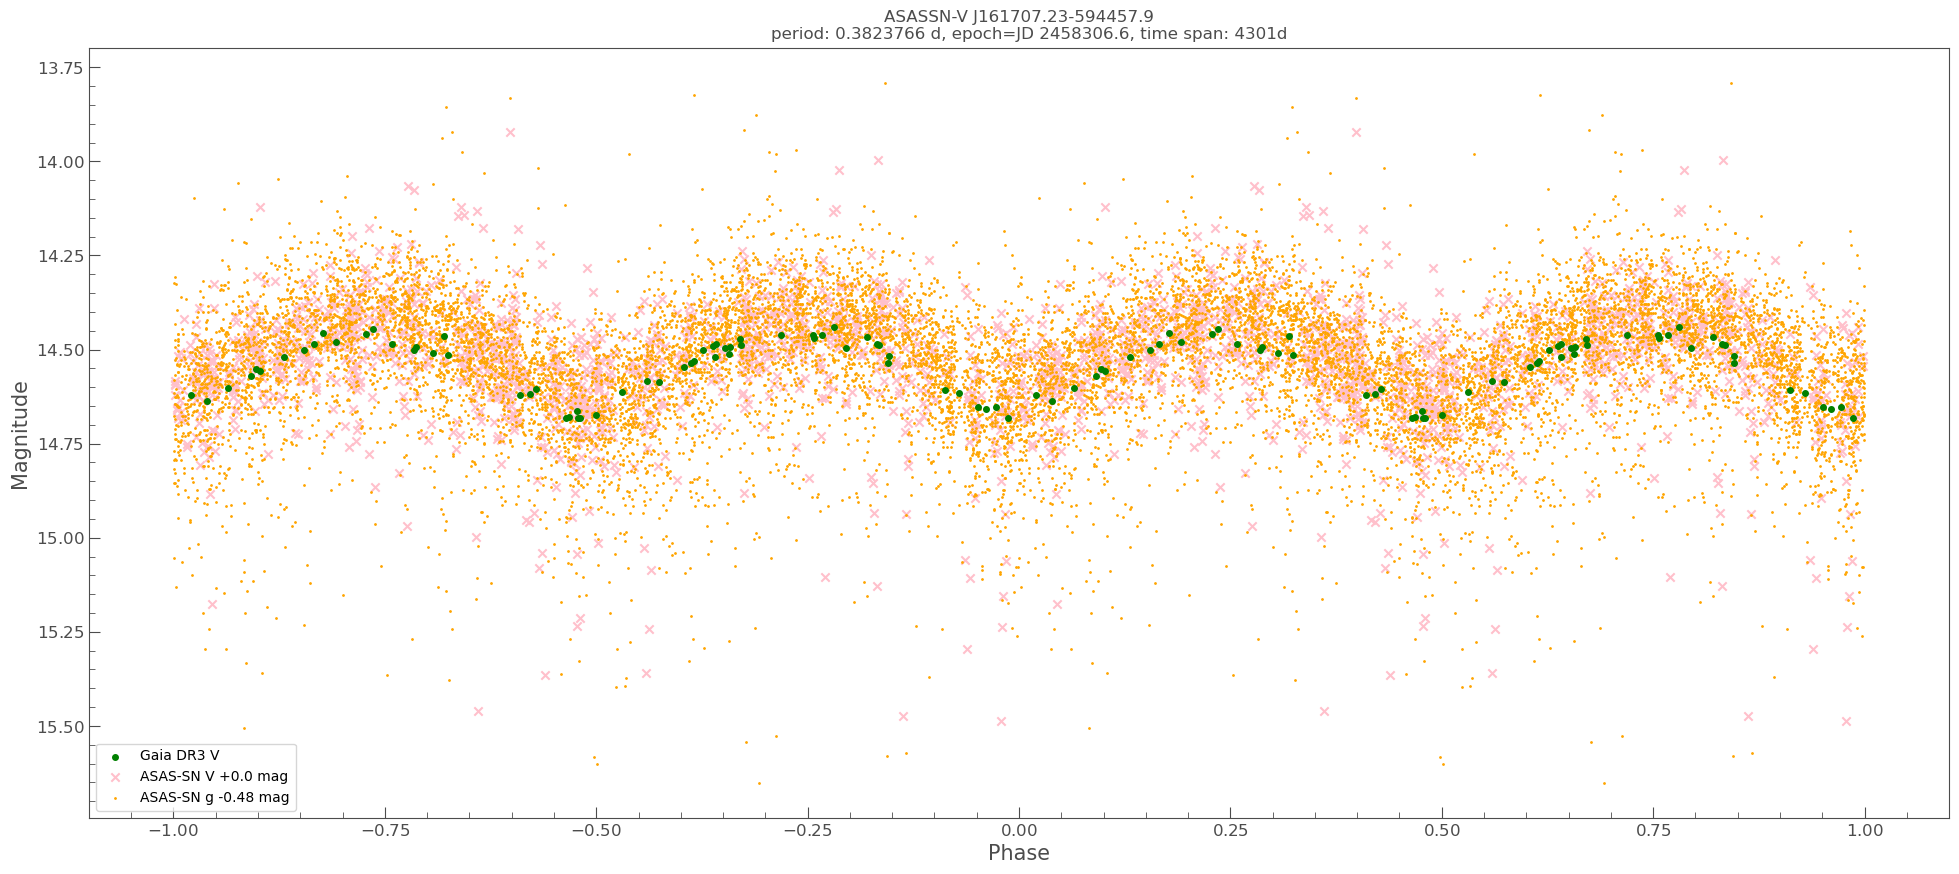

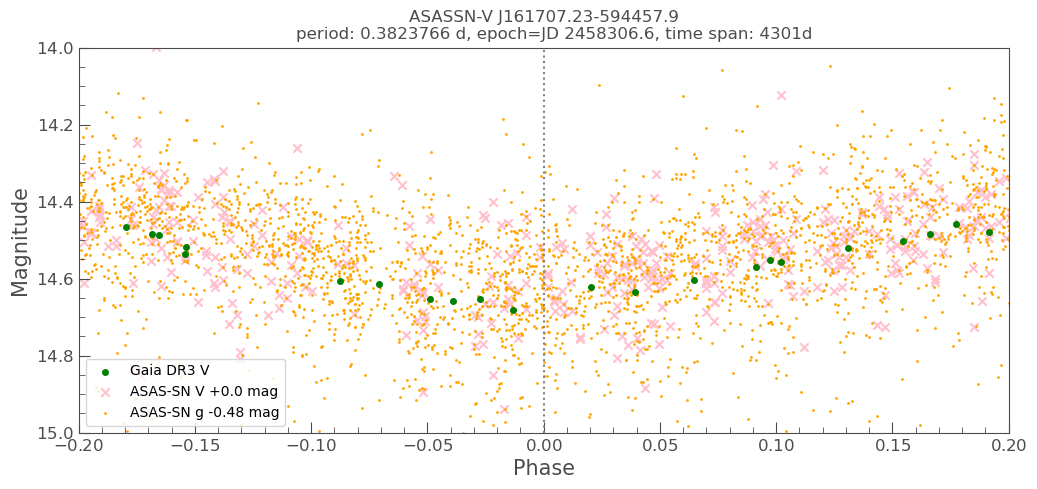

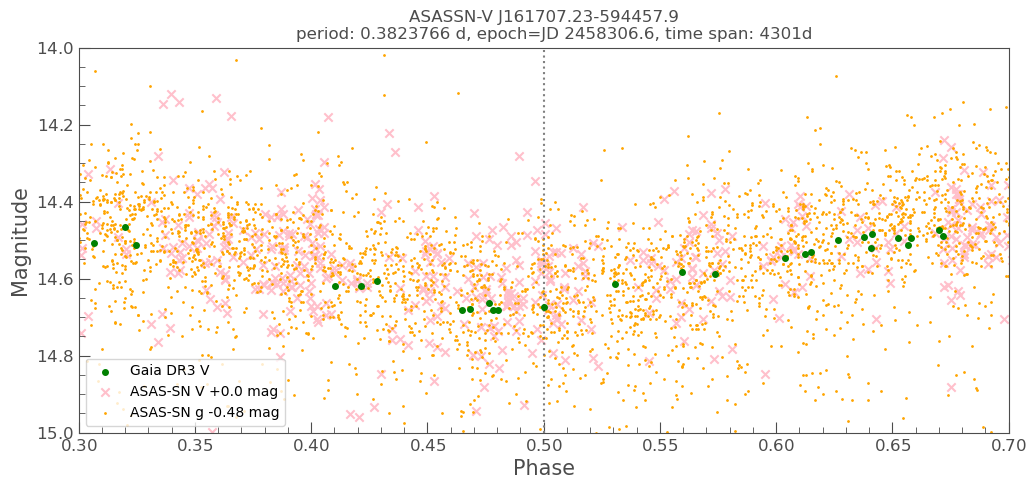

In [29]:
# reload(lkem)
from decimal import Decimal

# MCMC
# epoch:  2458306.596478733 +/- 0.0002471349821651831
# period:  0.38237662036731473 +/-  6.141545212352755e-08
#
# period_final = 0.3823748   # nifty-ls value based on the nearby QLP data in sectors 39, 66, 93

period_final = 0.3823766    # from MCMC value , errorbar is 6e-08, so keep the 7th digit
epoch_time_hjd_final = Decimal("2458306.60")  # from MCMC value, MCMC suggests 3 decimal points, but I feel 2 decimal point is proabbly more approprate given the cadence of the underlying data
duration_hr_min_i_final = duration_hr_min_i_trial 

epoch_time_min_ii_hjd_final = round(float(epoch_time_hjd_final) + period_final * 0.5, 2)
epoch_phase_min_ii_final   = abs(epoch_time_min_ii_hjd_final   - float(epoch_time_hjd_final)  ) / period_final   % 1
# if epoch_phase_min_ii_final   > 0.5:
#     epoch_phase_min_ii_final   = epoch_phase_min_ii_final   - 1
epoch_phase_min_ii_final  = round(epoch_phase_min_ii_final, 1)  # circular, also looks fine in folded LC below
duration_hr_min_ii_final = duration_hr_min_ii_trial


print("Adopted period / epoch / duration_hr: ", period_final, epoch_time_hjd_final, epoch_phase_min_ii_final, duration_hr_min_i_final, duration_hr_min_ii_final)

# --- plot to verify ---

plot_options = [
    ('scatter', {'c': 'green', 'marker': '.', 's': 64, 'alpha': 1.0, 'zorder': 9}),
    ('scatter', {'c': 'pink', 'marker': 'x', 's': 36, 'alpha': 1.0}),
    ('scatter', {'c': 'orange', 'marker': '.', 's': 4, 'alpha': 1.0}),
]

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final   , format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (None, None)
ax.set_ylim(*ylim);

# zoom plot Min I
# - make TESS more visible:  larger dots
plot_options_zoom = plot_options


ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    # lke.get_lc_dict_subset(lc_combined_dict, "TESS"),
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_i_final  ,  # for plotting only
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(0, c="gray", linestyle="dotted");
ax.set_xlim(-0.2, 0.2);  # to see primary in details
ylim = (15, 14)
ax.set_ylim(*ylim);

# # Min I super zoom
# ax = tplt.scatter(lc_f_res["TESS"].truncate(-0.001, 0.001), c="#3AF");
# ax.axvline(0, c="gray", linestyle="dotted");
# ax.set_title(f"Min I: {epoch_time_hjd_final}");

# zoom plot Min II
ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
    target_name=primary_name,
    duration_hr=duration_hr_min_ii_final  ,  # for plotting only
    duration_midpoint_phase=epoch_phase_min_ii_final,
    figsize=(12, 5),
    plot_options=plot_options_zoom,
    # mag_shift_precision=2,
);
ax.legend(loc="lower left");
ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
ax.set_xlim(epoch_phase_min_ii_final -0.2, epoch_phase_min_ii_final + 0.2);  # to see secondary in details
ax.set_ylim(*ylim);


In [ ]:
# demonstrate the precision difference in duration percentage 
# - 0 or 1 digit for percetnarge would be appropriate
# for _precision in [0, 1, 2, 3, 4]: 
#     _dur_pct = round(100 * duration_hr_min_i_final / 24 / period_final, _precision)
#     _dur_hr = _dur_pct /100 * 24 * period_final
#     # zoom plot Min I
#     # - make TESS more visible:  larger dots
#     plot_options_zoom = lkem.get_default_plot_multi_bands_options_copy()
#     plot_options_zoom[0][1]["s"] = 25
#     ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#         lc_combined_dict,
#         period=period_final,
#         epoch=Time(epoch_time_hjd_final  , format="jd", scale="utc"),
#         phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#         target_name=primary_name,
#         duration_hr=_dur_hr,  # for plotting only
#         figsize=(12, 5),
#         plot_options=plot_options_zoom,
#         # mag_shift_precision=2,  #
#     );
#     ax.set_ylim(*ylim);
#     ax.legend(loc="lower left");
#     ax.axvline(0, c="gray", linestyle="dotted");
#     ax.set_xlim(-0.075, 0.075);  # to see primary in details
#     ax.set_title(ax.get_title() + f",  duration: {_dur_pct}%, {_dur_hr:.1f} h");
#     # print(_dur_pct, _dur_hr, duration_hr_min_i_final) 

## Determine Range (Gaia DR3)


14.44 14.68


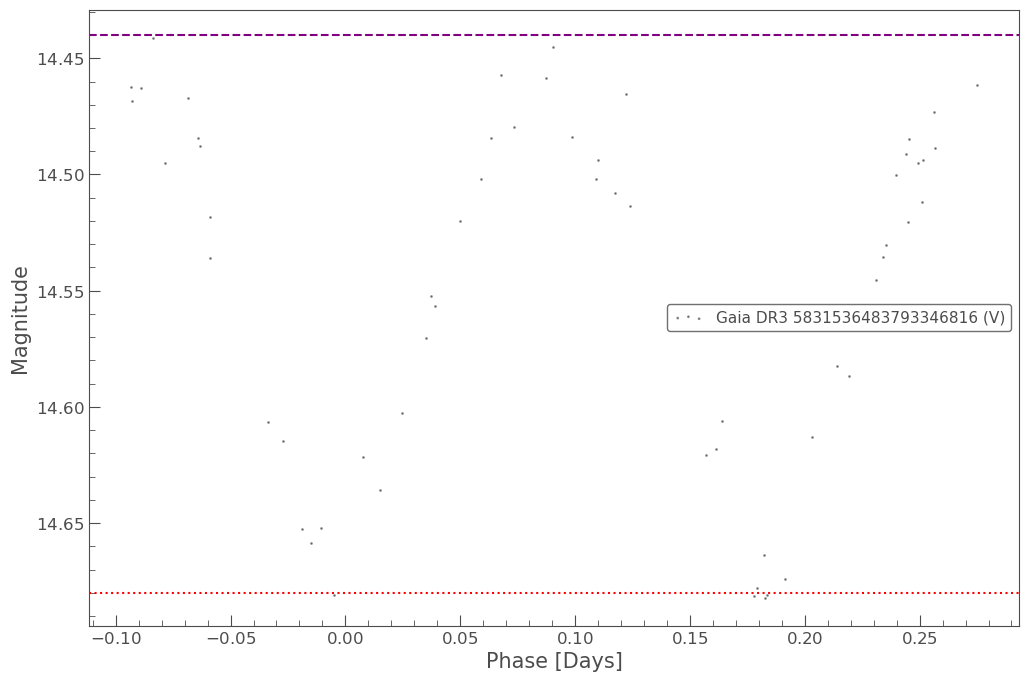

In [37]:
# %matplotlib widget
%matplotlib inline

# From Gaia DR3 data, the data does not seem to have much outliers, and seem to reach min/max, so I took the min/max as-is
lc = lc_combined_dict["Gaia DR3 V"]

max_flux_vmag = np.round(lc.flux.min().value, 2)
min_flux_vmag = np.round(lc.flux.max().value, 2)

lc_f = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final, wrap_phase=period_final*0.75)
ax = tplt.lk_ax(figsize=(12, 8))
ax = tplt.scatter(lc_f, ax=ax, alpha=0.5);
ax.axhline(max_flux_vmag, c="purple", linestyle="--", label="Max")
ax.axhline(min_flux_vmag, c="red", linestyle="dotted", label="Min")

print(max_flux_vmag, min_flux_vmag)

# # median_flux_vmag = np.nanmedian(lc.flux.value)

# # no max neded, medain is basically max
# # lc_zoom_max = lc.fold(epoch_time=epoch_time_hjd_final + 0.75, period=period_final).truncate(0 - 1 /24/60, 0 + 1 /24/ 60)  
# # print("Max mag # num data points:", len(lc_zoom_max))
# # max_flux_vmag = np.nanmedian(lc_zoom_max.flux.value)

# lc_zoom_min = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final).truncate(0 - 3 /24/60, 0 + 3 /24/ 60)
# print("Min I mag # num data points:", len(lc_zoom_min))
# min_flux_vmag = np.nanmedian(lc_zoom_min.flux.value)

# lc_zoom_min_ii = lc.fold(epoch_time=epoch_time_min_ii_hjd_final, period=period_final).truncate(0 - 3 /24/60, 0 + 3 /24/ 60)
# print("Min II mag # num data points:", len(lc_zoom_min_ii))
# min_ii_flux_vmag = np.nanmedian(lc_zoom_min_ii.flux.value)


# lc_f = lc.fold(epoch_time=epoch_time_hjd_final, period=period_final * 2)  # 2x period plot
# ax = tplt.lk_ax(figsize=(12, 8))
# ax = tplt.scatter(lc_f, ax=ax, alpha=0.5);
# # ax.axhline(max_flux_vmag, c="purple", linestyle="--", label="Max")
# ax.axhline(median_flux_vmag, c="blue", linestyle="dotted", label="Median")
# ax.axhline(min_flux_vmag, c="red", linestyle="dotted", label="Min I")
# ax.axhline(min_ii_flux_vmag, c="orange", linestyle="dotted", label="Min II")
# ax.legend(loc="lower right");
# # ax.set_xlim(-0.5, 0.5); 
# ax.set_ylim(*ylim);


# ax = tplt.errorbar(lc_zoom_min, marker="o");
# ax.axhline(min_flux_vmag, c="red", linestyle="dotted", label="Min I")
# # ax.set_ylim(*ylim);
# ax.legend();

# ax = tplt.errorbar(lc_zoom_min_ii, marker="o");
# ax.axhline(min_ii_flux_vmag, c="red", linestyle="dotted", label="Min II")
# ax.legend(loc="lower right");

# print([f"{v:.4f}" for v in [median_flux_vmag, min_flux_vmag, min_ii_flux_vmag]])  # 


# # # TESS only data, to report mean V mag and ampitude in TESS
# # mean_flux_v_vmag = np.round(rs_all_cols["Vmag"][0], 2)  # V converted from Gaia DR3 - here I use other sources

# # amp_flux_vmag = np.round(np.abs(float(min_flux_vmag - max_flux_vmag)) , 3)  # in TESS band, probably don't have 4 digit precison

# amp_min_i_flux_vmag = np.round(np.abs(float(min_flux_vmag - median_flux_vmag)) , 3)  

# amp_min_ii_flux_vmag = np.round(np.abs(float(min_ii_flux_vmag - median_flux_vmag)) , 3)  

# (amp_min_i_flux_vmag, amp_min_ii_flux_vmag)  # amp_flux_vmag,

## Plots for VSX

In [40]:
# custom default plot ptions
plot_options = [
    ('scatter', {'c': 'green', 'marker': '.', 's': 64, 'alpha': 1.0, 'zorder': 9}),
    ('scatter', {'c': 'pink', 'marker': 'x', 's': 36, 'alpha': 1.0}),
    ('scatter', {'c': 'orange', 'marker': '.', 's': 4, 'alpha': 1.0}),
]

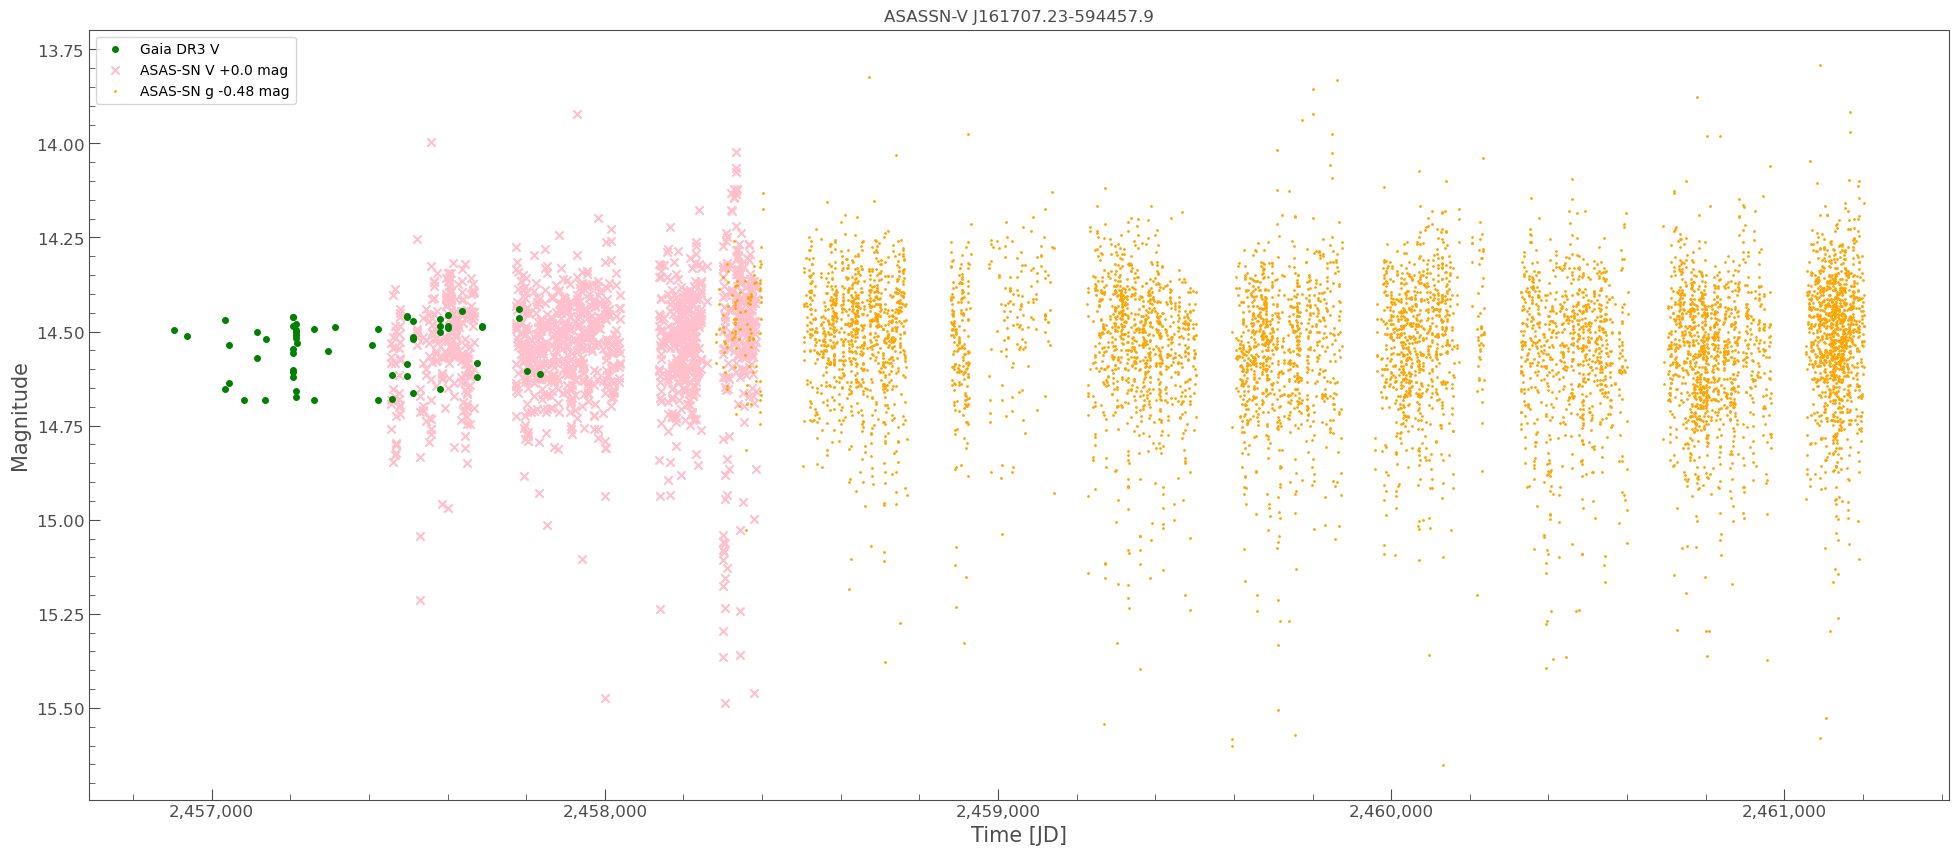

In [41]:
# reload(lkem)
# Not needed
# plot_options = lkem.get_default_plot_multi_bands_options_copy()

ax = lkem.plot_multi_bands(lc_combined_dict, figsize=(24, 10), target_name=primary_name, plot_options=plot_options);
# ax.set_title(ax.get_title() + "");

#### Phase Plot



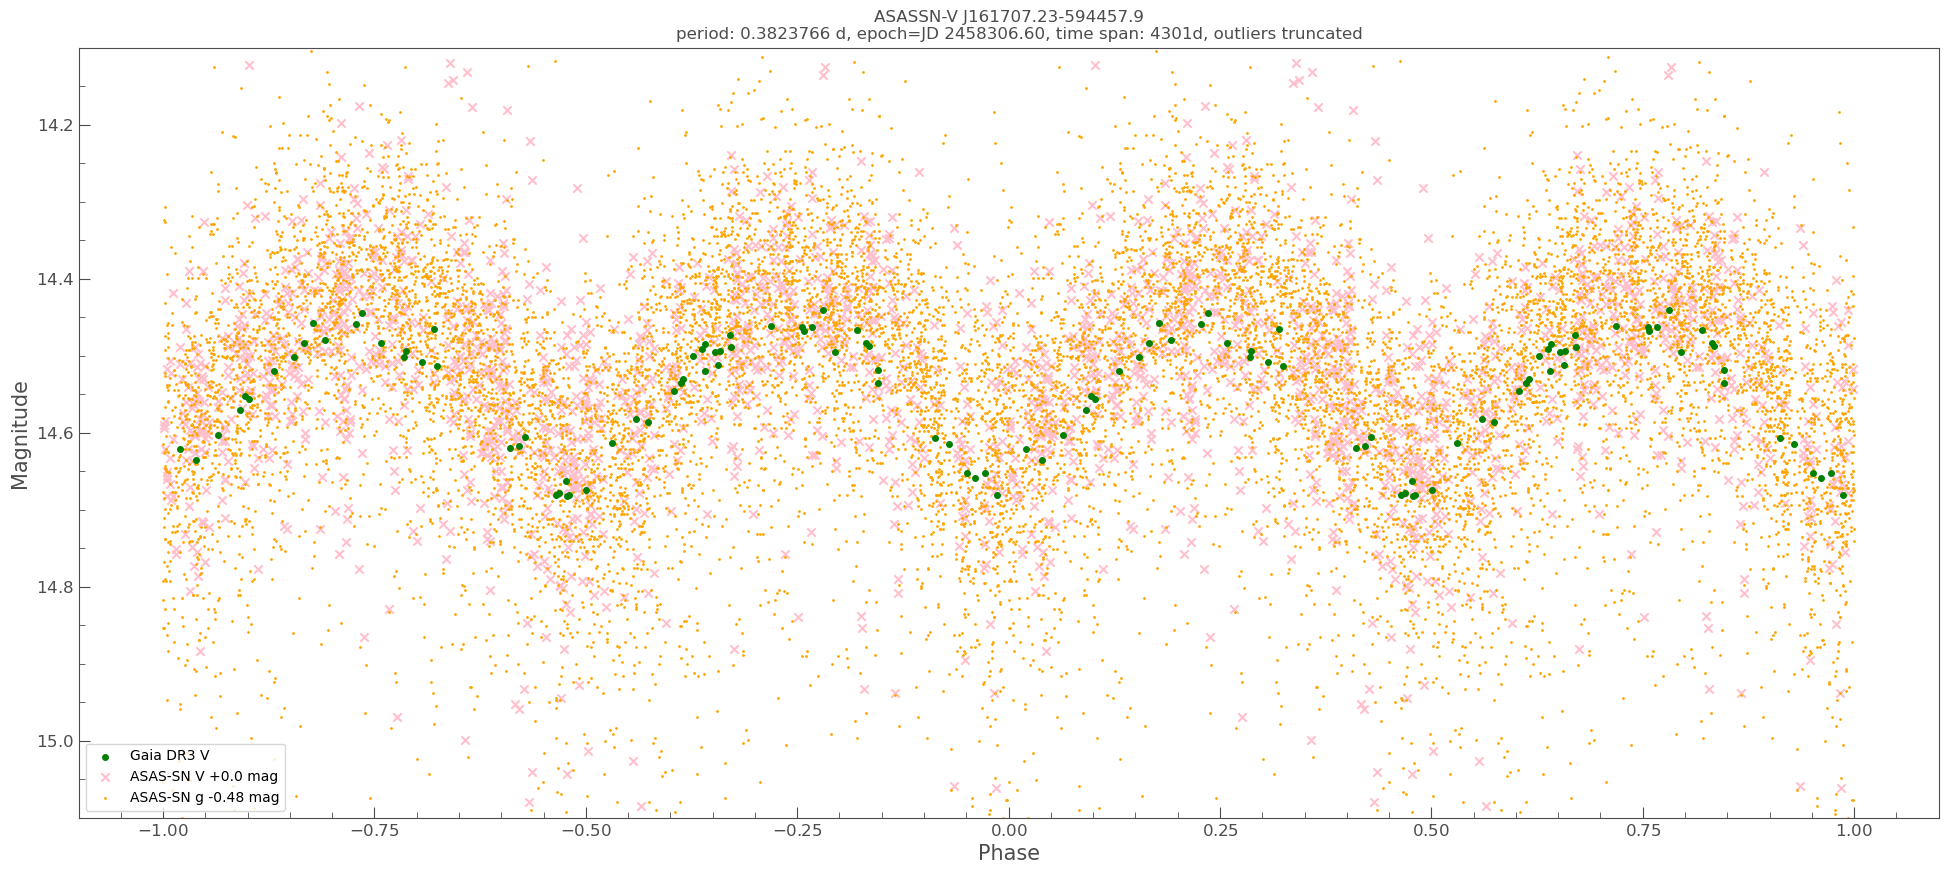

In [68]:
# reload(lkem)

ax, lc_f_res = lkem.fold_n_plot_multi_bands(
    lc_combined_dict,
    period=period_final,
    epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
    phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1    
    figsize=(24, 10),
    target_name=primary_name,
    epoch_value_str=f"JD {epoch_time_hjd_final}",  # for plotting output only to shwo the trialing 0 kept in the Decimal object
    plot_options=plot_options,
);
ax.legend(loc="lower left");
ylim = (15.1, 14.1)  # hide the outliers 
ax.set_ylim(*ylim);
ax.set_title(ax.get_title() + ", outliers truncated");


In [47]:
# # zoom plot Min I
# # - make TESS more visible:  larger dots
# plot_options_zoom = plot_options


# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_final,
#     epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     # duration_hr=duration_hr_min_i_final  ,  # for plotting only
#     figsize=(24, 10),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# # ax.axvline(0, c="gray", linestyle="dotted");
# ax.set_xlim(-0.1, 0.1);  # to see primary in details
# ylim = (None, None)
# ylim = (14.18, 14.07)
# ax.set_ylim(*ylim);
# ax.set_title(ax.get_title() + ", outliers truncated");


# # zoom plot Min II
# ax, lc_f_res = lkem.fold_n_plot_multi_bands(
#     lc_combined_dict,
#     period=period_final,
#     epoch=Time(epoch_time_hjd_final, format="jd", scale="utc"),
#     phase_scale=2,  #  fold at  period, i.e., plot from phase -1 to +1
#     target_name=primary_name,
#     # duration_hr=duration_hr_min_ii_final ,  # for plotting only
#     # duration_midpoint_phase=epoch_phase_min_ii_final,
#     figsize=(24, 10),
#     plot_options=plot_options_zoom,
#     # mag_shift_precision=2,
# );
# ax.legend(loc="lower left");
# # ax.axvline(epoch_phase_min_ii_final, c="gray", linestyle="dotted");
# ax.set_xlim(epoch_phase_min_ii_final - 0.1, epoch_phase_min_ii_final + 0.1);  # to see secondary in details
# ylim = (14.16, 14.07)
# ax.set_ylim(*ylim);
# ax.set_title(ax.get_title() + ", outliers truncated");


## VSX Report Table

In [48]:
def report_to_df(report):
    df = pd.DataFrame()
    df["Field"] = report.keys()
    df["Value"] = report.values()
    return df


def vsx_phase(phase):
    # the phase I used above is from [-0.5, +0.5]
    # convert to the phase [0, 1[ used by VSX
    if phase < -0.5 or phase > 0.5:
        raise ValueError(f"Input phase needs to be in [-0.5, 0.5] range. Actual: {phase}")
    if phase >= 0:
        return phase 
    else: 
        return 1 + phase


In [54]:
import bibs_utils
# reload(bibs_utils)

                                                                                 
other_names = "Gaia DR3 5831536483793346816,TIC 208155474"  # in ExoFOP + SIMMBAD

remarks = (
    f"""ASAS-SN magnitudes contaminated by Gaia DR3 5831536483793347200 (V= 17.0; sep. 3.0"), Gaia DR3 5831536483751936384 (V= 18.6; sep. 5.9"), Gaia DR3 5831536483793347712 (V= 14.6; sep. 6.5") and Gaia DR3 5831536479445987840 (V= 17.8; sep. 7.3"). Range has been corrected."""
)

# Not neeed for initial submission:
# - Type, period, epoch, eclipse duration from TESS and ZTF data. Range from ZTF g data.
revision_comment = "Identification from 2022yCat.1358....0G. Range derived from Gaia DR3 data. Period, epoch from ASAS-SN and Gaia DR3 data. Spectral type from 2023A&A...674A..26C. Gaia DR3 position."

BIBS = bibs_utils.BIBS
vsx_report = dict(
    Position=f"{target_coord.ra.value:.6f}, {target_coord.dec.value:.6f}",  # VSX coordinate precision is between 5 - 6 digits in deg (2 digits in s of hms / RA, 1 digit in s / DEC)
    # Primary_Name=primary_name,  # no change
    Other_Names=other_names,
    # Variable_Type="EW",  # no change
    Spectral_Type="G",  # From Gaia DR3
    Spectral_Type_Uncertain=False,
    Maximum_Magnitude=f"{max_flux_vmag}", 
    Maximum_Magnitude_band="V",
    Minimum_Magnitude=f"{min_flux_vmag}",
    Minimum_Magnitude_band="V",  
    Minimum_Is_Amplitude=False,
    Period=f"{period_final}",  
    Epoch=f"{epoch_time_hjd_final}",
    # Rise_Duration_Pct=f"{100 * duration_hr_min_i_final / 24 / period_final:.0f}",  # N/A for EW type
    # Discoverer="",  
    Remarks=remarks,
    Revision_Comment=revision_comment,
    Reference0_Name=BIBS.ASAS_SN_N,
    Reference0_Bib=BIBS.ASAS_SN_B,
    Reference1_Name=BIBS.GAIA_DR3_N,
    Reference1_Bib=BIBS.GAIA_DR3_B,
    Reference2_Name=BIBS.GAIA_DR3_VAR_N,
    Reference2_Bib=BIBS.GAIA_DR3_VAR_B,
    Reference3_Name=BIBS.GAIA_DR3_ASTROPHY_N,
    Reference3_Bib=BIBS.GAIA_DR3_ASTROPHY_B,
)


def print_long_fields(report):
    other_names_list = report["Other_Names"].split(",")
    print("Other Names (1 line each):")
    print("\n".join(other_names_list))
    print("")
    print(report["Remarks"])
    print("")
    print(report["Revision_Comment"])

print_long_fields(vsx_report)
with pd.option_context('display.max_colwidth', None):
    display(report_to_df(vsx_report))


print("""
tic208155474_phase_plot_eclipses.png : EW Phase Plot - EW Phase Plot from transformed Gaia DR3 V and ASAS-SN data, shifted to transformed Gaia DR3 V. Outliers truncated.
""")


Other Names (1 line each):
Gaia DR3 5831536483793346816
TIC 208155474

ASAS-SN magnitudes contaminated by Gaia DR3 5831536483793347200 (V= 17.0; sep. 3.0"), Gaia DR3 5831536483751936384 (V= 18.6; sep. 5.9"), Gaia DR3 5831536483793347712 (V= 14.6; sep. 6.5") and Gaia DR3 5831536479445987840 (V= 17.8; sep. 7.3"). Range has been corrected.

Identification from 2022yCat.1358....0G. Range derived from Gaia DR3 data. Period, epoch from ASAS-SN and Gaia DR3 data. Spectral type from 2023A&A...674A..26C. Gaia DR3 position.


,Field,Value
0,Position,"244.278981, -59.750604"
1,Other_Names,"Gaia DR3 5831536483793346816,TIC 208155474"
2,Spectral_Type,G
3,Spectral_Type_Uncertain,False
4,Maximum_Magnitude,14.44
5,Maximum_Magnitude_band,V
6,Minimum_Magnitude,14.68
7,Minimum_Magnitude_band,V
8,Minimum_Is_Amplitude,False
9,Period,0.3823766



tic208155474_phase_plot_eclipses.png : EW Phase Plot - EW Phase Plot from transformed Gaia DR3 V and ASAS-SN data, shifted to transformed Gaia DR3 V. Outliers truncated.

